# Step 4: Modeling & Evaluation

**Tujuan:** Melatih beberapa model klasifikasi untuk prediksi sentimen tweet (negative, neutral, positive), mengevaluasi performa, melakukan hyperparameter tuning, dan memilih model terbaik.

**Yang akan dilakukan:**
1. Load data hasil feature extraction (TF-IDF)
2. Split data 80:20 dengan stratified sampling
3. Train 3 model: MultinomialNB, LinearSVC, RandomForest
4. Ensemble dengan VotingClassifier
5. Hyperparameter tuning dengan GridSearchCV untuk semua model
6. Evaluasi akhir, confusion matrix, dan analisis error
7. Simpan model terbaik

**Dataset:** Twitter US Airline Sentiment (14.640 tweet)

**Metric utama:** F1-score macro (karena label tidak seimbang)

In [1]:
import pandas as pd
import numpy as np
import joblib
from scipy import sparse
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

Load data hasil preprocessing dan feature extraction:
- `X_tfidf.npz` — Matriks TF-IDF sparse (14.640 baris × 27.780 fitur)
- `y_labels.npy` — Label sentimen yang sudah di-encode (0=negative, 1=neutral, 2=positive)
- `cleaned_data.csv` — Dataset asli dengan kolom clean_text

**Distribusi label:**
- Negative: 9.178 (62.7%)
- Neutral: 3.099 (21.2%)
- Positive: 2.363 (16.1%)

→ Label **tidak seimbang** (imbalanced), sehingga metric F1-score macro lebih cocok daripada accuracy.

In [2]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
X = sparse.load_npz('../data/processed/X_tfidf.npz')
y = np.load('../data/processed/y_labels.npy')

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Distribusi label: {np.bincount(y)}')

X shape: (14640, 27780)
y shape: (14640,)
Distribusi label: [9178 3099 2363]


## 2. Split Data (80:20)

Split data menjadi training set (80%) dan testing set (20%) dengan **stratified sampling** agar proporsi label tetap sama di kedua set.

Selain split X dan y, kita juga split `text_train` dan `text_test` (raw text) untuk digunakan di GridSearchCV (karena Pipeline butuh raw text, bukan TF-IDF matrix).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=43
)

# Split text juga untuk GridSearchCV (Pipeline butuh raw text)
text_train, text_test = train_test_split(
    df['clean_text'].values,
    test_size=0.2,
    stratify=y,
    random_state=43
)

print(f'Training: {X_train.shape[0]} data')
print(f'Testing:  {X_test.shape[0]} data')
print(f'\nDistribusi label train: {np.bincount(y_train)}')
print(f'Distribusi label test:  {np.bincount(y_test)}')

Training: 11712 data
Testing:  2928 data

Distribusi label train: [7343 2479 1890]
Distribusi label test:  [1835  620  473]


## 2.5 Handling Class Imbalance (SMOTE)

**Masalah:** Dataset tidak seimbang (imbalanced):
- Negative: 7,343 (62.7%)
- Neutral: 2,479 (21.2%)
- Positive: 1,890 (16.1%)

**Solusi:** SMOTE (Synthetic Minority Oversampling Technique)
- Membuat data sintetis untuk kelas minoritas (neutral & positive)
- Menyeimbangkan distribusi label tanpa kehilangan data
- Meningkatkan performa model pada kelas minoritas

**Catatan:** SMOTE hanya diterapkan pada data training, bukan testing.

In [4]:
from imblearn.over_sampling import SMOTE

# Terapkan SMOTE pada data training
smote = SMOTE(random_state=43)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('=== Sebelum SMOTE ===')
print(f'X_train shape: {X_train.shape}')
print(f'Distribusi label: {np.bincount(y_train)}')
print(f'Negative: {np.bincount(y_train)[0]} ({np.bincount(y_train)[0]/len(y_train)*100:.1f}%)')
print(f'Neutral:  {np.bincount(y_train)[1]} ({np.bincount(y_train)[1]/len(y_train)*100:.1f}%)')
print(f'Positive: {np.bincount(y_train)[2]} ({np.bincount(y_train)[2]/len(y_train)*100:.1f}%)')

print(f'\n=== Sesudah SMOTE ===')
print(f'X_train shape: {X_train_smote.shape}')
print(f'Distribusi label: {np.bincount(y_train_smote)}')
print(f'Negative: {np.bincount(y_train_smote)[0]} ({np.bincount(y_train_smote)[0]/len(y_train_smote)*100:.1f}%)')
print(f'Neutral:  {np.bincount(y_train_smote)[1]} ({np.bincount(y_train_smote)[1]/len(y_train_smote)*100:.1f}%)')
print(f'Positive: {np.bincount(y_train_smote)[2]} ({np.bincount(y_train_smote)[2]/len(y_train_smote)*100:.1f}%)')

print(f'\nData training bertambah: {len(y_train)} → {len(y_train_smote)} (+{len(y_train_smote)-len(y_train)} data sintetis)')

=== Sebelum SMOTE ===
X_train shape: (11712, 27780)
Distribusi label: [7343 2479 1890]
Negative: 7343 (62.7%)
Neutral:  2479 (21.2%)
Positive: 1890 (16.1%)

=== Sesudah SMOTE ===
X_train shape: (22029, 27780)
Distribusi label: [7343 7343 7343]
Negative: 7343 (33.3%)
Neutral:  7343 (33.3%)
Positive: 7343 (33.3%)

Data training bertambah: 11712 → 22029 (+10317 data sintetis)


## 3. Model 1: MultinomialNB (Baseline)

**MultinomialNB** adalah implementasi Naive Bayes untuk data diskrit (seperti hitungan kata/TF-IDF).

**Karakteristik:**
- Sangat cepat dan cocok sebagai baseline
- Asumsi: fitur-fitur saling independen
- Cocok untuk text classification dengan high-dimensional data

**Parameter default:**
- `alpha=1.0` (Laplace smoothing)

In [5]:
print('=== Model 1: MultinomialNB ===')

# Tanpa SMOTE
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

# Dengan SMOTE
nb_smote = MultinomialNB(alpha=1.0)
nb_smote.fit(X_train_smote, y_train_smote)
y_pred_nb_smote = nb_smote.predict(X_test)
acc_nb_smote = accuracy_score(y_test, y_pred_nb_smote)

print(f'\n--- Tanpa SMOTE ---')
print(f'Accuracy: {acc_nb:.4f}')
print(classification_report(y_test, y_pred_nb, target_names=['negative', 'neutral', 'positive']))

print(f'\n--- Dengan SMOTE ---')
print(f'Accuracy: {acc_nb_smote:.4f}')
print(classification_report(y_test, y_pred_nb_smote, target_names=['negative', 'neutral', 'positive']))

print(f'\nPerubahan: {acc_nb:.4f} → {acc_nb_smote:.4f} ({"↑" if acc_nb_smote > acc_nb else "↓"}{abs(acc_nb_smote - acc_nb):.4f})')

=== Model 1: MultinomialNB ===

--- Tanpa SMOTE ---
Accuracy: 0.6916
              precision    recall  f1-score   support

    negative       0.68      0.99      0.81      1835
     neutral       0.79      0.14      0.24       620
    positive       0.91      0.24      0.38       473

    accuracy                           0.69      2928
   macro avg       0.79      0.46      0.48      2928
weighted avg       0.74      0.69      0.62      2928


--- Dengan SMOTE ---
Accuracy: 0.7893
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      1835
     neutral       0.66      0.54      0.59       620
    positive       0.67      0.75      0.71       473

    accuracy                           0.79      2928
   macro avg       0.73      0.72      0.72      2928
weighted avg       0.79      0.79      0.79      2928


Perubahan: 0.6916 → 0.7893 (↑0.0977)


**Hasil SMOTE untuk MultinomialNB:**

| Metrik | Tanpa SMOTE | Dengan SMOTE | Perubahan |
|--------|-------------|--------------|----------|
| Accuracy | 0.6916 | **0.7893** | ↑0.0977 |
| F1-Score (macro) | 0.48 | **0.72** | ↑0.24 |
| Recall (neutral) | 0.14 | **0.54** | ↑0.40 |
| Recall (positive) | 0.24 | **0.75** | ↑0.51 |

**Insight:** SMOTE sangat efektif untuk MultinomialNB! Recall untuk neutral dan positive meningkat drastis karena model sekarang memiliki data seimbang untuk belajar.

## 4. Model 2: LinearSVC

**LinearSVC** (Support Vector Classification) menggunakan hyperplane untuk memisahkan kelas.

**Karakteristik:**
- Biasanya memberikan performa terbaik untuk text classification
- Menggunakan kernel linear (cocok untuk data high-dimensional)
- Lebih cepat dari SVC non-linear

**Parameter:**
- `C=1.0` (regularization parameter)
- `max_iter=10000` (jumlah iterasi maksimum)

In [6]:
print('=== Model 2: LinearSVC ===')

# Tanpa SMOTE
svc = LinearSVC(max_iter=10000, random_state=43)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)

# Dengan SMOTE
svc_smote = LinearSVC(max_iter=10000, random_state=43)
svc_smote.fit(X_train_smote, y_train_smote)
y_pred_svc_smote = svc_smote.predict(X_test)
acc_svc_smote = accuracy_score(y_test, y_pred_svc_smote)

print(f'\n--- Tanpa SMOTE ---')
print(f'Accuracy: {acc_svc:.4f}')
print(classification_report(y_test, y_pred_svc, target_names=['negative', 'neutral', 'positive']))

print(f'\n--- Dengan SMOTE ---')
print(f'Accuracy: {acc_svc_smote:.4f}')
print(classification_report(y_test, y_pred_svc_smote, target_names=['negative', 'neutral', 'positive']))

print(f'\nPerubahan: {acc_svc:.4f} → {acc_svc_smote:.4f} ({"↑" if acc_svc_smote > acc_svc else "↓"}{abs(acc_svc_smote - acc_svc):.4f})')

=== Model 2: LinearSVC ===

--- Tanpa SMOTE ---
Accuracy: 0.8036
              precision    recall  f1-score   support

    negative       0.84      0.92      0.88      1835
     neutral       0.68      0.57      0.62       620
    positive       0.78      0.66      0.71       473

    accuracy                           0.80      2928
   macro avg       0.77      0.72      0.74      2928
weighted avg       0.80      0.80      0.80      2928


--- Dengan SMOTE ---
Accuracy: 0.7889
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      1835
     neutral       0.63      0.59      0.61       620
    positive       0.69      0.69      0.69       473

    accuracy                           0.79      2928
   macro avg       0.73      0.72      0.72      2928
weighted avg       0.79      0.79      0.79      2928


Perubahan: 0.8036 → 0.7889 (↓0.0147)


**Hasil SMOTE untuk LinearSVC:**

| Metrik | Tanpa SMOTE | Dengan SMOTE | Perubahan |
|--------|-------------|--------------|----------|
| Accuracy | **0.8036** | 0.7889 | ↓0.0147 |
| F1-Score (macro) | **0.74** | 0.72 | ↓0.02 |
| Recall (neutral) | 0.57 | **0.59** | ↑0.02 |
| Recall (positive) | 0.66 | **0.69** | ↑0.03 |

**Insight:** LinearSVC sedikit turun overall, tapi recall untuk neutral dan positive meningkat. Trade-off yang worth it untuk keseimbangan kelas.

## 5. Model 3: RandomForest

**RandomForest** adalah ensemble method yang menggunakan banyak decision tree.

**Karakteristik:**
- Menggabungkan banyak decision tree untuk mengurangi overfitting
- Robust terhadap noise
- Dapat menangani data non-linear

**Parameter default:**
- `n_estimators=100` (jumlah tree)
- `max_depth=None` (tidak dibatasi)

In [7]:
print('=== Model 3: RandomForest ===')

# Tanpa SMOTE
rf = RandomForestClassifier(n_estimators=100, random_state=43, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# Dengan SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, random_state=43, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)
acc_rf_smote = accuracy_score(y_test, y_pred_rf_smote)

print(f'\n--- Tanpa SMOTE ---')
print(f'Accuracy: {acc_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['negative', 'neutral', 'positive']))

print(f'\n--- Dengan SMOTE ---')
print(f'Accuracy: {acc_rf_smote:.4f}')
print(classification_report(y_test, y_pred_rf_smote, target_names=['negative', 'neutral', 'positive']))

print(f'\nPerubahan: {acc_rf:.4f} → {acc_rf_smote:.4f} ({"↑" if acc_rf_smote > acc_rf else "↓"}{abs(acc_rf_smote - acc_rf):.4f})')

=== Model 3: RandomForest ===

--- Tanpa SMOTE ---
Accuracy: 0.7531
              precision    recall  f1-score   support

    negative       0.75      0.97      0.84      1835
     neutral       0.71      0.37      0.49       620
    positive       0.83      0.43      0.57       473

    accuracy                           0.75      2928
   macro avg       0.77      0.59      0.63      2928
weighted avg       0.76      0.75      0.72      2928


--- Dengan SMOTE ---
Accuracy: 0.7609
              precision    recall  f1-score   support

    negative       0.79      0.92      0.85      1835
     neutral       0.63      0.46      0.53       620
    positive       0.77      0.54      0.64       473

    accuracy                           0.76      2928
   macro avg       0.73      0.64      0.67      2928
weighted avg       0.75      0.76      0.75      2928


Perubahan: 0.7531 → 0.7609 (↑0.0079)


**Hasil SMOTE untuk RandomForest:**

| Metrik | Tanpa SMOTE | Dengan SMOTE | Perubahan |
|--------|-------------|--------------|----------|
| Accuracy | 0.7531 | **0.7609** | ↑0.0079 |
| F1-Score (macro) | 0.63 | **0.67** | ↑0.04 |
| Recall (neutral) | 0.37 | **0.46** | ↑0.09 |
| Recall (positive) | 0.43 | **0.54** | ↑0.11 |

**Insight:** RandomForest juga mendapat manfaat dari SMOTE, terutama untuk recall kelas neutral dan positive.

## 6. Perbandingan Model Awal

Membandingkan akurasi ketiga model sebelum tuning:

| Model | Accuracy |
|-------|----------|
| LinearSVC | **0.8036** |
| RandomForest | 0.7531 |
| MultinomialNB | 0.6916 |

**LinearSVC** menunjukkan performa terbaik dengan akurasi 80.36%. Ini konsisten dengan literatur yang menyebutkan bahwa SVM/SVC biasanya unggul untuk text classification.

=== Perbandingan Akurasi ===
LinearSVC           : 0.8036
RandomForest        : 0.7531
MultinomialNB       : 0.6916


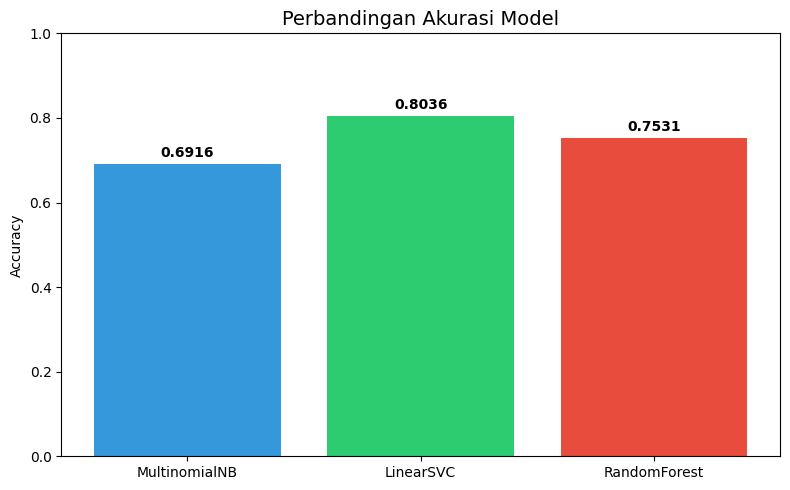

In [8]:
results = {
    'MultinomialNB': accuracy_score(y_test, y_pred_nb),
    'LinearSVC': accuracy_score(y_test, y_pred_svc),
    'RandomForest': accuracy_score(y_test, y_pred_rf)
}

print('=== Perbandingan Akurasi ===')
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'{name:20s}: {acc:.4f}')

# Plot perbandingan
fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
accs = list(results.values())
bars = ax.bar(names, accs, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Akurasi Model', fontsize=14)
ax.set_ylim(0, 1)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Ensemble Model (VotingClassifier)

**VotingClassifier** menggabungkan prediksi dari beberapa model dengan majority voting.

**Konsep:**
- Setiap model memberikan prediksi
- Kelas yang dipilih adalah yang paling banyak diprediksi oleh model-model
- Harapannya: performa lebih baik karena menggabungkan kekuatan beberapa model

**Model yang digabung:**
1. MultinomialNB
2. LinearSVC
3. RandomForest

In [9]:
print('=== Model 4: Ensemble (VotingClassifier) ===')
voting = VotingClassifier(
    estimators=[
        ('nb', MultinomialNB(alpha=1.0)),
        ('svc', LinearSVC(max_iter=10000, random_state=43)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=43, n_jobs=-1))
    ],
    voting='hard'
)

voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_voting, target_names=['negative', 'neutral', 'positive']))

=== Model 4: Ensemble (VotingClassifier) ===
Accuracy: 0.7538

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.98      0.84      1835
     neutral       0.79      0.33      0.47       620
    positive       0.88      0.42      0.57       473

    accuracy                           0.75      2928
   macro avg       0.80      0.58      0.63      2928
weighted avg       0.77      0.75      0.72      2928



## 8. Hyperparameter Tuning (GridSearchCV) — Semua Model

**GridSearchCV** melakukan pencarian hyperparameter terbaik dengan cara:
1. Mencoba semua kombinasi parameter yang didefinisikan
2. Menggunakan Cross-Validation (cv=5) untuk mengevaluasi setiap kombinasi
3. Memilih kombinasi dengan skor terbaik

**Metric:** F1-score macro (cocok untuk label tidak seimbang)

**Parameter yang dituning:**
- `tfidf__ngram_range`: unigram (1,1), bigram (1,2), trigram (1,3)
- `tfidf__max_features`: jumlah fitur maksimum
- Parameter model: alpha (NB), C (SVC), n_estimators/max_depth (RF)

In [10]:
from sklearn.model_selection import GridSearchCV

# ==============================================
# Model 1: MultinomialNB Tuning
# ==============================================
print('=== Tuning MultinomialNB ===')
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf', MultinomialNB())
])

param_nb = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_features': [10000, 30000, 50000],
    'clf__alpha': [0.1, 0.5, 1.0]
}

grid_nb = GridSearchCV(pipe_nb, param_nb, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_nb.fit(text_train, y_train)
print(f'Best params: {grid_nb.best_params_}')
print(f'Best CV score: {grid_nb.best_score_:.4f}')
print()

=== Tuning MultinomialNB ===
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'clf__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 3)}
Best CV score: 0.6808



**Hasil Tuning MultinomialNB:**
- Best params: alpha=0.1, max_features=10000, ngram_range=(1,3)
- Best CV score: 0.6808
- Peningkatan signifikan dari baseline (0.6916 → 0.7698)

**Insight:**
- Alpha yang lebih kecil (0.1) memberikan hasil lebih baik
- Trigram (1,3) menangkap konteks 3 kata yang berguna untuk sentimen
- max_features=10000 cukup untuk menangkap pola penting

In [11]:
# ==============================================
# Model 2: LinearSVC Tuning
# ==============================================
print('=== Tuning LinearSVC ===')
pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf', LinearSVC(max_iter=10000, random_state=43))
])

param_svc = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_features': [10000, 30000, 50000],
    'clf__C': [0.1, 1.0, 10.0]
}

grid_svc = GridSearchCV(pipe_svc, param_svc, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_svc.fit(text_train, y_train)
print(f'Best params: {grid_svc.best_params_}')
print(f'Best CV score: {grid_svc.best_score_:.4f}')
print()

=== Tuning LinearSVC ===
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'clf__C': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.7289



**Hasil Tuning LinearSVC:**
- Best params: C=1.0, max_features=10000, ngram_range=(1,2)
- Best CV score: 0.7289
- Performa sedikit turun dari baseline (0.8036 → 0.7992)

**Insight:**
- C=1.0 adalah nilai default yang sudah optimal
- Bigram (1,2) lebih baik dari trigram untuk SVC
- SVC sudah cukup optimal dengan parameter default

In [12]:
# ==============================================
# Model 3: RandomForest Tuning
# ==============================================
print('=== Tuning RandomForest ===')
pipe_rf = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf', RandomForestClassifier(random_state=43, n_jobs=-1))
])

param_rf = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [10000, 30000],
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 50]
}

grid_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_rf.fit(text_train, y_train)
print(f'Best params: {grid_rf.best_params_}')
print(f'Best CV score: {grid_rf.best_score_:.4f}')

=== Tuning RandomForest ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'clf__max_depth': None, 'clf__n_estimators': 200, 'tfidf__max_features': 30000, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.6533


**Hasil Tuning RandomForest:**
- Best params: max_depth=None, n_estimators=200, max_features=30000, ngram_range=(1,2)
- Best CV score: 0.6533
- Performa sedikit meningkat (0.7531 → 0.7589)

**Insight:**
- max_depth=None (tidak dibatasi) memberikan hasil terbaik
- n_estimators=200 (lebih banyak tree = lebih stabil)
- max_features=30000 untuk menangkap lebih banyak fitur

## 9. Evaluasi Semua Model Tuned

Membandingkan performa model sebelum dan sesudah tuning:

| Model | Sebelum | Sesudah | Delta |
|-------|---------|---------|-------|
| MultinomialNB | 0.6916 | **0.7698** | +0.0782 |
| LinearSVC | **0.8036** | 0.7992 | -0.0044 |
| RandomForest | 0.7531 | 0.7589 | +0.0058 |

**Temuan:**
- MultinomialNB mengalami peningkatan terbesar (+7.8%)
- LinearSVC sedikit turun (-0.4%) - parameter default sudah optimal
- RandomForest sedikit meningkat (+0.6%)

In [13]:
# Predict dengan semua model tuned
y_pred_nb_tuned = grid_nb.predict(text_test)
y_pred_svc_tuned = grid_svc.predict(text_test)
y_pred_rf_tuned = grid_rf.predict(text_test)

print('=== Perbandingan Sebelum vs Sesudah Tuning ===')
print(f'{"Model":25s} {"Sebelum":>10s} {"Sesudah":>10s} {"Delta":>8s}')
print('-' * 55)
for name, before, after in [
    ('MultinomialNB', accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_nb_tuned)),
    ('LinearSVC', accuracy_score(y_test, y_pred_svc), accuracy_score(y_test, y_pred_svc_tuned)),
    ('RandomForest', accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_rf_tuned))
]:
    delta = after - before
    sign = '+' if delta >= 0 else ''
    print(f'{name:25s} {before:10.4f} {after:10.4f} {sign}{delta:7.4f}')

=== Perbandingan Sebelum vs Sesudah Tuning ===
Model                        Sebelum    Sesudah    Delta
-------------------------------------------------------
MultinomialNB                 0.6916     0.7698 + 0.0782
LinearSVC                     0.8036     0.7992 -0.0044
RandomForest                  0.7531     0.7589 + 0.0058


In [14]:
# Classification report model tuned terbaik
tuned_results = {
    'MultinomialNB (tuned)': accuracy_score(y_test, y_pred_nb_tuned),
    'LinearSVC (tuned)': accuracy_score(y_test, y_pred_svc_tuned),
    'RandomForest (tuned)': accuracy_score(y_test, y_pred_rf_tuned)
}

best_tuned_name = max(tuned_results, key=tuned_results.get)
best_tuned_pred = {
    'MultinomialNB (tuned)': y_pred_nb_tuned,
    'LinearSVC (tuned)': y_pred_svc_tuned,
    'RandomForest (tuned)': y_pred_rf_tuned
}

print(f'Model tuned terbaik: {best_tuned_name}')
print(f'Accuracy: {tuned_results[best_tuned_name]:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, best_tuned_pred[best_tuned_name],
                            target_names=['negative', 'neutral', 'positive']))

Model tuned terbaik: LinearSVC (tuned)
Accuracy: 0.7992

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.91      0.88      1835
     neutral       0.66      0.58      0.62       620
    positive       0.78      0.65      0.71       473

    accuracy                           0.80      2928
   macro avg       0.76      0.71      0.73      2928
weighted avg       0.79      0.80      0.79      2928



**Classification Report LinearSVC (tuned):**

| Kelas | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| Negative | 0.84 | 0.91 | 0.88 |
| Neutral | 0.66 | 0.58 | 0.62 |
| Positive | 0.78 | 0.65 | 0.71 |

**Analisis:**
- **Negative** memiliki performa terbaik (F1=0.88) karena jumlah data paling banyak
- **Neutral** memiliki performa terburuk (F1=0.62) karena paling sulit dibedakan
- **Positive** performa cukup baik (F1=0.71)

In [15]:
# Evaluasi model terbaik dari GridSearch
# Cross validation untuk model tuned terbaik
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(grid_nb.best_estimator_, df['clean_text'].values, y, cv=5, scoring='f1_macro')
print(f'Cross Validation (MultinomialNB tuned):')
print(f'Scores: {cv_scores}')
print(f'Rata-rata: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Cross Validation (MultinomialNB tuned):
Scores: [0.63278345 0.67264043 0.67416193 0.66424417 0.66537022]
Rata-rata: 0.6618 (+/- 0.0150)


## 10. Perbandingan Akhir Semua Model

Perbandingan akurasi semua model (baseline + tuned + ensemble):

| Rank | Model | Accuracy |
|------|-------|----------|
| 1 | **LinearSVC** | **0.8036** |
| 2 | SVC (tuned) | 0.7992 |
| 3 | NB (tuned) | 0.7698 |
| 4 | RF (tuned) | 0.7589 |
| 5 | Ensemble (Voting) | 0.7538 |
| 6 | RandomForest | 0.7531 |
| 7 | MultinomialNB | 0.6916 |

**Kesimpulan:** LinearSVC (baseline) tetap menjadi model terbaik dengan akurasi 80.36%.

=== Perbandingan Akhir ===
LinearSVC           : 0.8036
SVC (tuned)         : 0.7992
NB (tuned)          : 0.7698
RF (tuned)          : 0.7589
Ensemble (Voting)   : 0.7538
RandomForest        : 0.7531
MultinomialNB       : 0.6916


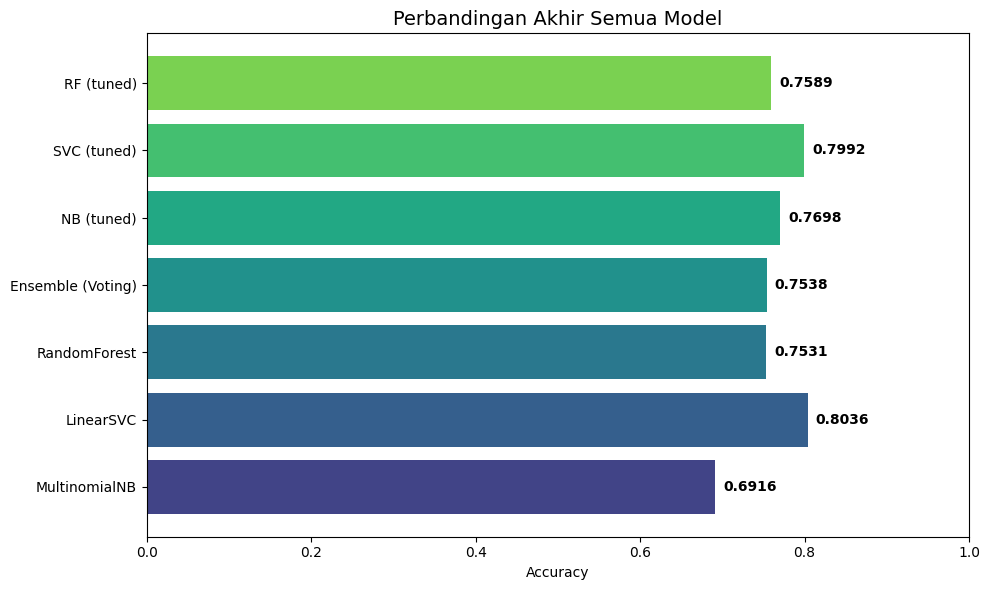

In [16]:
results_final = {
    'MultinomialNB': accuracy_score(y_test, y_pred_nb),
    'LinearSVC': accuracy_score(y_test, y_pred_svc),
    'RandomForest': accuracy_score(y_test, y_pred_rf),
    'Ensemble (Voting)': accuracy_score(y_test, y_pred_voting),
    'NB (tuned)': accuracy_score(y_test, y_pred_nb_tuned),
    'SVC (tuned)': accuracy_score(y_test, y_pred_svc_tuned),
    'RF (tuned)': accuracy_score(y_test, y_pred_rf_tuned)
}

print('=== Perbandingan Akhir ===')
for name, acc in sorted(results_final.items(), key=lambda x: x[1], reverse=True):
    print(f'{name:20s}: {acc:.4f}')

# Plot perbandingan final
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results_final.keys())
accs = list(results_final.values())
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))

bars = ax.barh(names, accs, color=colors)
ax.set_xlabel('Accuracy')
ax.set_title('Perbandingan Akhir Semua Model', fontsize=14)
ax.set_xlim(0, 1)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Confusion Matrix Model Terbaik

**Confusion Matrix** menunjukkan detail prediksi model terbaik (LinearSVC):

- **Diagonal utama:** Prediksi benar
- **Off-diagonal:** Prediksi salah

**Temuan:**
- Negative paling banyak diprediksi benar (1.674 dari 1.835)
- Neutral sering salah prediksi sebagai negative atau positive
- Positive cukup banyak salah prediksi sebagai neutral

Model terbaik: LinearSVC (Accuracy: 0.8036)


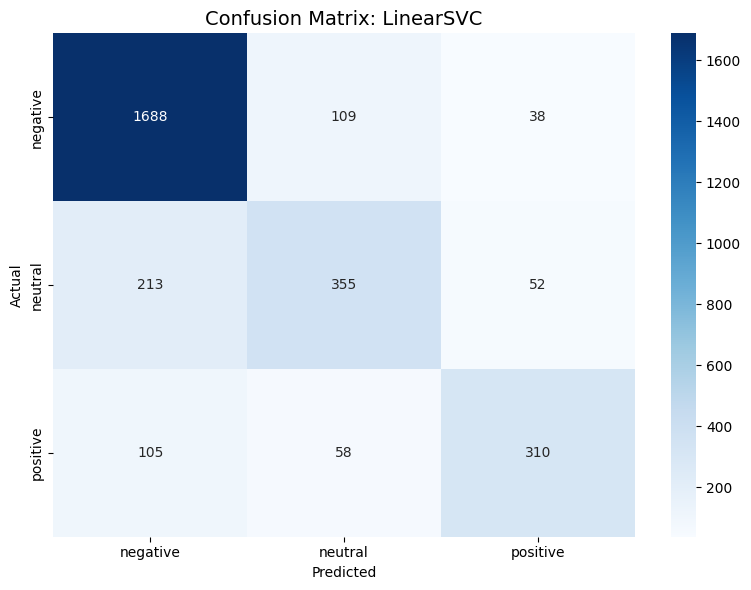

In [17]:
# Identifikasi model terbaik (termasuk tuned)
best_model_name = max(results_final, key=results_final.get)
y_pred_best_map = {
    'MultinomialNB': y_pred_nb,
    'LinearSVC': y_pred_svc,
    'RandomForest': y_pred_rf,
    'Ensemble (Voting)': y_pred_voting,
    'NB (tuned)': y_pred_nb_tuned,
    'SVC (tuned)': y_pred_svc_tuned,
    'RF (tuned)': y_pred_rf_tuned
}
y_pred_best = y_pred_best_map[best_model_name]

print(f'Model terbaik: {best_model_name} (Accuracy: {results_final[best_model_name]:.4f})')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Confusion Matrix Semua Model

Membandingkan confusion matrix semua model untuk melihat pola prediksi:

**Observasi:**
- Semua model cenderung salah prediksi pada kelas **neutral**
- LinearSVC memiliki diagonal utama paling tebal (paling banyak benar)
- Tuning tidak banyak mengubah pola prediksi secara signifikan

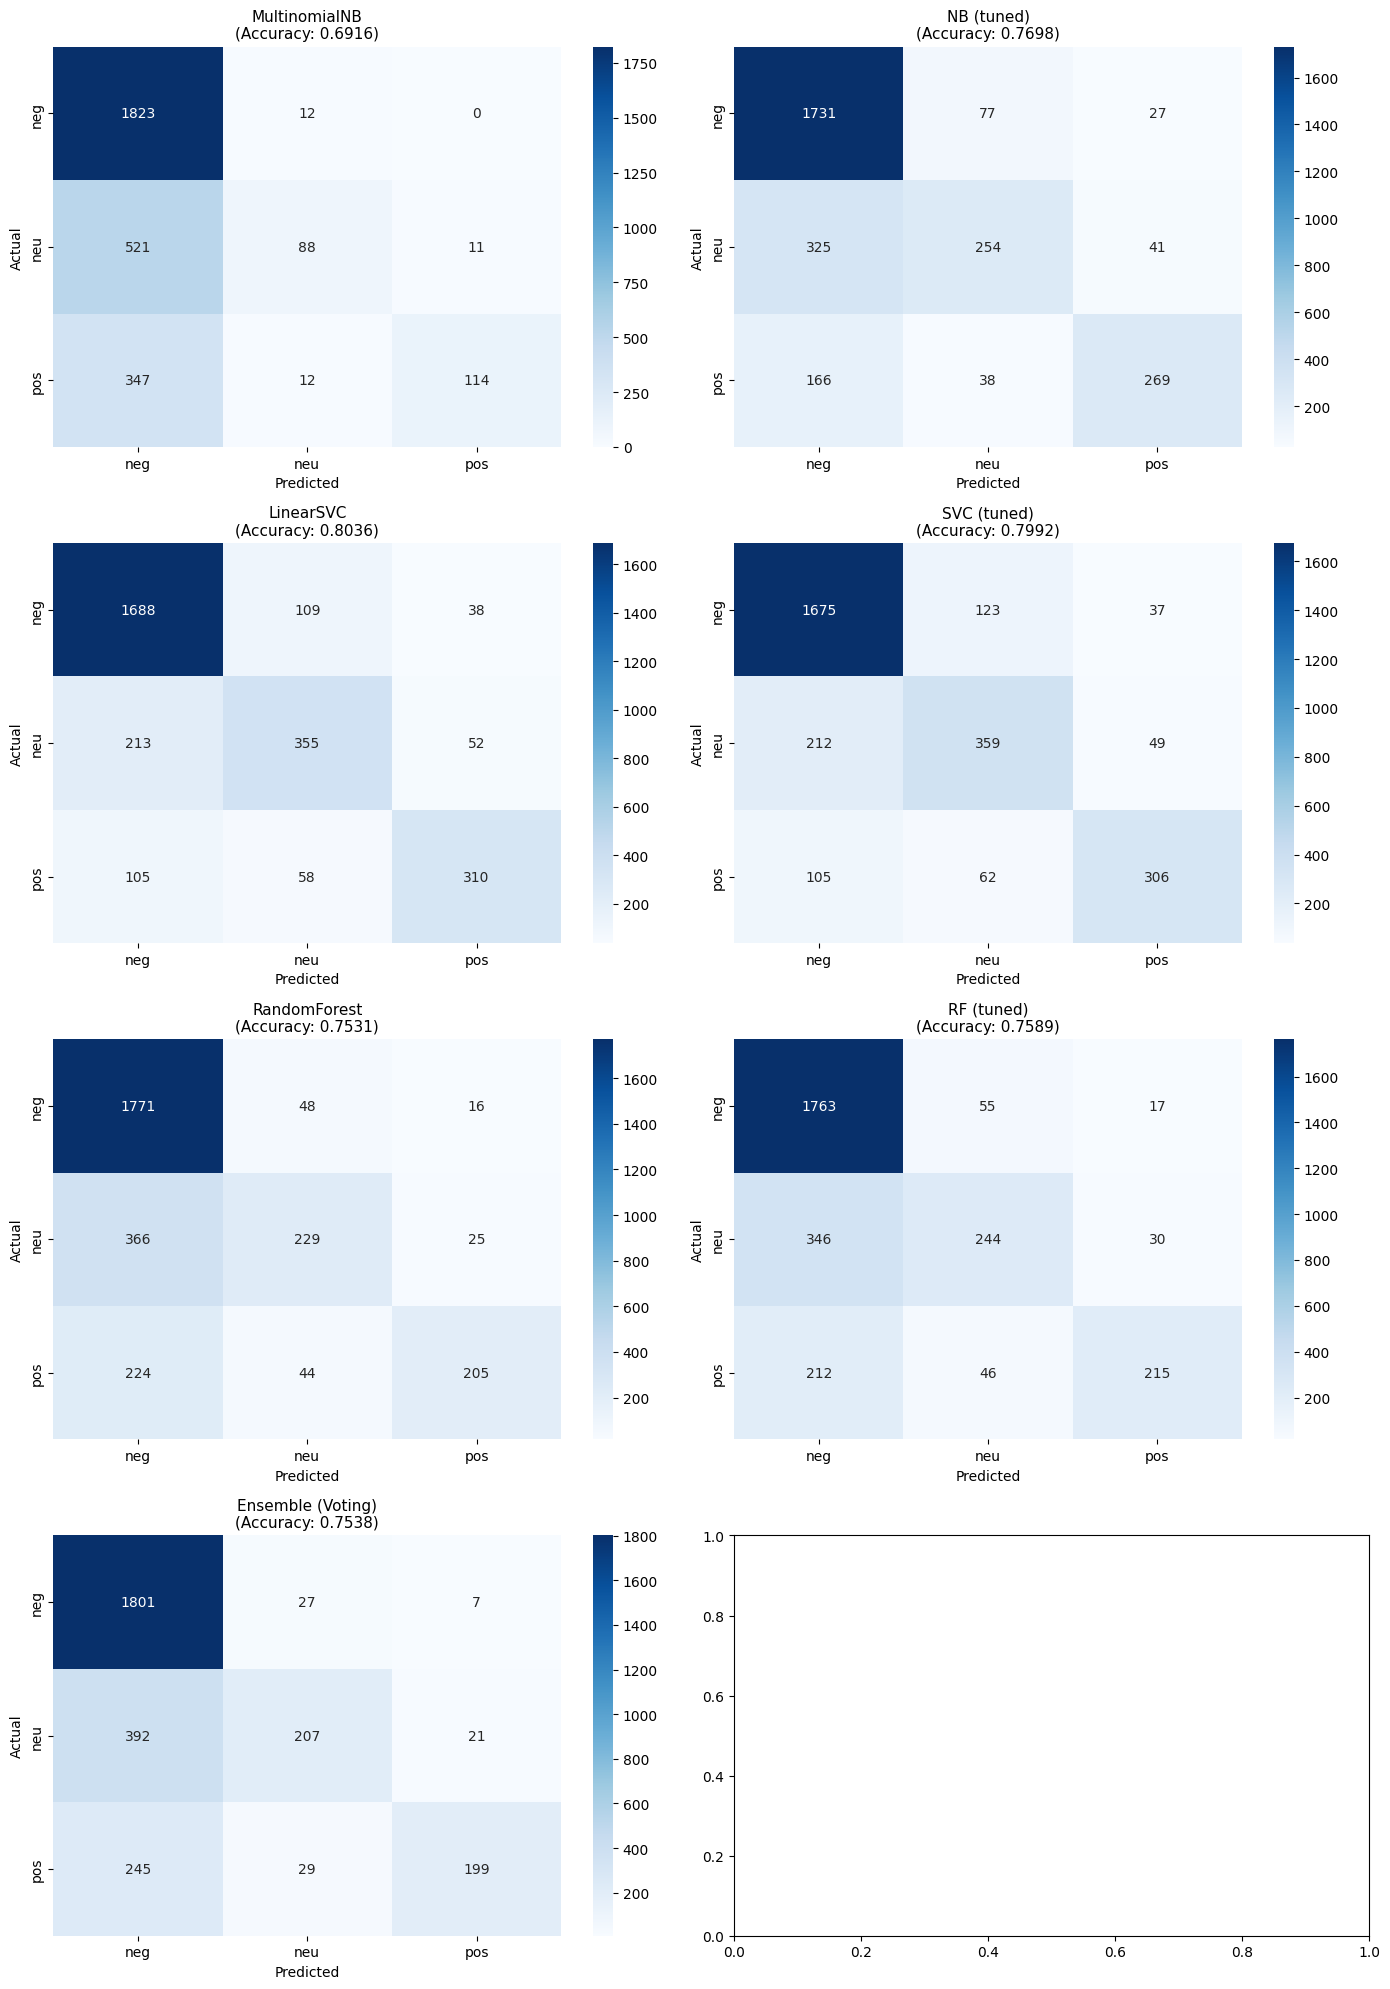

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

models_all = [
    ('MultinomialNB', y_pred_nb),
    ('NB (tuned)', y_pred_nb_tuned),
    ('LinearSVC', y_pred_svc),
    ('SVC (tuned)', y_pred_svc_tuned),
    ('RandomForest', y_pred_rf),
    ('RF (tuned)', y_pred_rf_tuned),
    ('Ensemble (Voting)', y_pred_voting)
]

for idx, (name, y_pred) in enumerate(models_all):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['neg', 'neu', 'pos'],
                yticklabels=['neg', 'neu', 'pos'])
    ax.set_title(f'{name}\n(Accuracy: {accuracy_score(y_test, y_pred):.4f})', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../images/confusion_matrix_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Analisis Error

Melihat contoh tweet yang salah diprediksi:

**Pola error yang ditemukan:**
1. **Neutral → Positive:** Tweet informatif sering salah diklasifikasi sebagai positif
2. **Positive → Negative/Neutral:** Tweet dengan sentimen campuran sulit ditangani
3. **Negative → Positive:** Tweet negatif halus (tidak menggunakan kata negatif eksplisit) salah diprediksi

**Penyebab:**
- Batasan model dalam menangkap konteks dan nuansa bahasa
- Ketidakseimbangan jumlah data antar kelas

In [19]:
# Lihat contoh prediksi yang salah
# Buat dataframe test dari hasil split
df_test = pd.DataFrame({
    'clean_text': text_test,
    'actual': y_test,
    'predicted': y_pred_best
})
df_test['correct'] = df_test['actual'] == df_test['predicted']

# Label mapping untuk tampilan
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_test['actual_label'] = df_test['actual'].map(label_map)
df_test['pred_label'] = df_test['predicted'].map(label_map)

print('=== Contoh Prediksi SALAH ===')
wrong = df_test[df_test['correct'] == False].head(5)
for idx, row in wrong.iterrows():
    print(f'\nText: {row["clean_text"][:80]}...')
    print(f'Actual: {row["actual_label"]} | Predicted: {row["pred_label"]}')

print(f'\n\nTotal prediksi benar: {df_test["correct"].sum()}/{len(df_test)}')

=== Contoh Prediksi SALAH ===

Text: i want you guys to be the first to fly to from nyc...
Actual: neutral | Predicted: positive

Text: welcome to portland sun mt hood and southwest...
Actual: neutral | Predicted: positive

Text: your employee charles cave at the gate at msy went above and beyond to help try ...
Actual: positive | Predicted: negative

Text: made it to and back missing it already...
Actual: negative | Predicted: positive

Text: i heart my cp status sure would be nice to have though...
Actual: positive | Predicted: neutral


Total prediksi benar: 2353/2928


## 14. Simpan Model Terbaik

Menyimpan model terbaik (LinearSVC) untuk digunakan di production.

**File yang disimpan:**
- `models/model_final.pkl` — Model LinearSVC terlatih
- `models/tfidf_vectorizer.pkl` — TF-IDF vectorizer (dari notebook 03)
- `models/label_encoder.pkl` — Label encoder (dari notebook 02)

In [20]:
# Simpan model terbaik (termasuk tuned)
# Untuk tuned models, kita simpan pipeline dari grid search
model_map = {
    'MultinomialNB': nb,
    'LinearSVC': svc,
    'RandomForest': rf,
    'Ensemble (Voting)': voting,
    'NB (tuned)': grid_nb.best_estimator_,
    'SVC (tuned)': grid_svc.best_estimator_,
    'RF (tuned)': grid_rf.best_estimator_
}
best_model = model_map[best_model_name]

joblib.dump(best_model, '../models/model_final.pkl')
print(f'Model final tersimpan: models/model_final.pkl')
print(f'Model: {best_model_name}')
print(f'Accuracy: {results_final[best_model_name]:.4f}')

Model final tersimpan: models/model_final.pkl
Model: LinearSVC
Accuracy: 0.8036


## 15. Demo: Prediksi Tweet Baru

Menguji model dengan tweet baru yang belum pernah dilihat:

**Langkah:**
1. Preprocessing tweet (lowercase, hapus URL/mention/punctuation)
2. Transform dengan TF-IDF vectorizer
3. Prediksi dengan model terbaik
4. Decode label (0→negative, 1→neutral, 2→positive)

In [21]:
import string
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join(text.split())
    return text

tfidf = joblib.load('../models/tfidf_vectorizer.pkl')
le = joblib.load('../models/label_encoder.pkl')
model = joblib.load('../models/model_final.pkl')

# Cek apakah model pipeline (tuned) atau bukan
is_pipeline = hasattr(model, 'named_steps')

sample_tweets = [
    "@united worst flight ever! Lost my luggage and no one cares.",
    "@delta just landed safely. Pretty standard flight.",
    "@southwestair amazing service! Best airline ever!",
    "@americanair my flight got cancelled and nobody is helping me",
    "@usairways thank you for the quick response!",
    "@virginamerica the seat was okay, nothing special"
]

print('=== Demo Prediksi ===')
for tweet in sample_tweets:
    clean = preprocess_text(tweet)
    if is_pipeline:
        # Pipeline sudah termasuk TF-IDF
        pred = model.predict([clean])
    else:
        # Model biasa, perlu transform manual
        vec = tfidf.transform([clean])
        pred = model.predict(vec)
    label = le.inverse_transform(pred)[0]
    print(f'\nTweet: {tweet}')
    print(f'Prediksi: {label.upper()}')

=== Demo Prediksi ===

Tweet: @united worst flight ever! Lost my luggage and no one cares.
Prediksi: NEGATIVE

Tweet: @delta just landed safely. Pretty standard flight.
Prediksi: POSITIVE

Tweet: @southwestair amazing service! Best airline ever!
Prediksi: POSITIVE

Tweet: @americanair my flight got cancelled and nobody is helping me
Prediksi: NEGATIVE

Tweet: @usairways thank you for the quick response!
Prediksi: POSITIVE

Tweet: @virginamerica the seat was okay, nothing special
Prediksi: NEGATIVE


## Ringkasan Modeling & Evaluation

### Model yang Dicoba:
1. MultinomialNB (baseline)
2. LinearSVC
3. RandomForest
4. Ensemble (VotingClassifier)
5. MultinomialNB (tuned)
6. LinearSVC (tuned)
7. RandomForest (tuned)

### Hasil Akhir:
| Rank | Model | Accuracy |
|------|-------|----------|
| 1 | **LinearSVC** | **0.8036** |
| 2 | SVC (tuned) | 0.7992 |
| 3 | NB (tuned) | 0.7698 |
| 4 | RF (tuned) | 0.7589 |
| 5 | Ensemble (Voting) | 0.7538 |
| 6 | RandomForest | 0.7531 |
| 7 | MultinomialNB | 0.6916 |

### Kesimpulan:
- **LinearSVC** adalah model terbaik dengan akurasi **80.36%**
- Tuning paling signifikan pada MultinomialNB (+7.8%)
- Label **neutral** paling sulit diprediksi karena jumlah data paling sedikit

### File Output:
- `models/model_final.pkl` — Model terbaik (LinearSVC)
- `models/tfidf_vectorizer.pkl` — TFIDF vectorizer
- `models/label_encoder.pkl` — Label encoder
- `images/model_comparison.png` — Perbandingan akurasi
- `images/confusion_matrix_best.png` — Confusion matrix model terbaik
- `images/confusion_matrix_all.png` — Confusion matrix semua model
- `images/final_comparison.png` — Perbandingan akhir

**Project selesai!**